In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
#from torchvision import datasets, transforms, utils
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import ParameterSampler, RandomizedSearchCV, cross_val_score
#from scipy.stats import uniform
from retriever import *
import random
np.random.seed(32)
random.seed(32)
import skopt
from skopt import gp_minimize
from sklearn.model_selection import ParameterSampler, cross_val_score
import nest_asyncio
nest_asyncio.apply()

### Bayesian optimization

In [41]:
#Setup

altitude_range = (14.688672, 15.181072)
latitude_range = (54.5, 55.327825)

domain = {
    "latitude": latitude_range,
    "altitude": altitude_range,
}

x0 = [np.random.choice(latitude_range),np.random.choice(altitude_range)]
y0 = request_elevation(x0[0],x0[1])

In [42]:
import csv

# Load points from CSV
points = []
with open("/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/active_machine_learning/week1/02463 Active machine learning and agency, Spring 2026 - 232026 - 157 PM/Active-Machine-Learning-Elevation/vald/elevation_data.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        lat, lon = float(row[0]), float(row[1])
        points.append([lat, lon])

points = np.array(points)  # shape (N, 2)

# Create an iterator so we can consume points in order
points_iter = iter(points)

In [43]:
i = 0  # counter

def objective_function(x):
    """
    x: a 2-element list or array from gp_minimize, e.g., [lat, lon]
    """
    global i
    x = np.array(x)

    # Find the closest CSV point
    distances = np.linalg.norm(points - x, axis=1)
    nearest_idx = np.argmin(distances)
    nearest_point = points[nearest_idx]

    elevation = request_elevation(nearest_point[0], nearest_point[1])
    i += 1
    print(f"\n\nindex = {i}, suggested x = {x}, snapped to CSV point = {nearest_point}, elevation = {elevation}")

    return -elevation  # negative because we want to maximize


np.int = int #numpy np.int deprecation workaround

opt = gp_minimize(objective_function, # the function to minimize
                  [latitude_range, altitude_range],
                                      # the bounds on each dimension of x
                  acq_func="EI",      # the acquisition function
                  n_initial_points=0, # no initial point except the one
                  n_calls=199,         # the number of evaluations of objective_function 19 since we give one initial point
                  x0=x0,           #initial point
                  y0=[y0],           #inital objective function value
                  xi=0.1,             #exploration parameter
                  noise=0.01**2)       # the noise level (optional)



index = 1, suggested x = [54.5      14.688672], snapped to CSV point = [54.963728 14.688672], elevation = -18


index = 2, suggested x = [55.31838263 15.17646532], snapped to CSV point = [55.32228496 15.17357972], elevation = 0


index = 3, suggested x = [54.5        15.05961337], snapped to CSV point = [54.97713525 14.70680378], elevation = -16.6154670715332


index = 4, suggested x = [55.327825 14.688672], snapped to CSV point = [55.09243179 14.86272932], elevation = 78.51607513427734


index = 5, suggested x = [55.18963559 14.688672  ], snapped to CSV point = [55.04358372 14.79666783], elevation = -0.5617144703865051


index = 6, suggested x = [55.327825   14.77300115], snapped to CSV point = [55.13274562 14.91724921], elevation = 121.3137283325195


index = 7, suggested x = [55.327825   14.82634341], snapped to CSV point = [55.15824595 14.95173551], elevation = 104.8304901123047


index = 8, suggested x = [55.30056814 14.78109951], snapped to CSV point = [55.12698229 14.90945495]

In [44]:
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
y_bo

array([ -0.        ,  -0.        ,  -0.        ,  -0.        ,
        78.51607513,  78.51607513, 121.31372833, 121.31372833,
       121.31372833, 121.31372833, 154.14297485, 154.14297485,
       154.14297485, 154.14297485, 154.14297485, 154.14297485,
       154.14297485, 154.14297485, 160.74806213, 160.74806213,
       160.74806213, 160.74806213, 160.74806213, 160.74806213,
       160.74806213, 160.74806213, 160.74806213, 160.74806213,
       160.74806213, 160.74806213, 160.74806213, 162.50088501,
       162.50088501, 162.50088501, 162.50088501, 162.50088501,
       162.50088501, 163.91661072, 163.91661072, 163.91661072,
       163.91661072, 163.91661072, 163.91661072, 163.93533325,
       163.93533325, 163.93533325, 163.93533325, 164.1207428 ,
       164.1207428 , 164.1207428 , 164.1207428 , 164.1207428 ,
       164.1207428 , 164.1207428 , 164.1207428 , 164.1207428 ,
       164.1207428 , 164.1207428 , 164.1207428 , 164.1207428 ,
       164.1207428 , 164.87893677, 164.87893677, 164.87

In [45]:
-opt.func_vals.ravel()

array([-0.00000000e+00, -1.80000000e+01, -0.00000000e+00, -1.66154671e+01,
        7.85160751e+01, -5.61714470e-01,  1.21313728e+02,  1.04830490e+02,
        1.09829407e+02,  8.05217361e+01,  1.54142975e+02,  6.20845642e+01,
        1.14520744e+02,  7.29673920e+01,  1.34540253e+02,  1.17735374e+02,
        1.09806160e+02,  7.32201462e+01,  1.60748062e+02,  9.50240097e+01,
        1.14121994e+02,  9.23980179e+01,  1.21384491e+02,  8.63820267e+01,
        1.18000000e+02,  1.44324921e+02,  1.17336220e+02,  7.91878204e+01,
        1.09607689e+02,  1.15000000e+02,  8.08886261e+01,  1.62500885e+02,
        1.49466400e+02,  1.39889282e+02,  1.30424088e+02,  1.37229263e+02,
        1.21687119e+02,  1.63916611e+02,  1.52061142e+02,  7.20697174e+01,
        1.58786407e+02,  1.09000000e+02,  8.14417801e+01,  1.63935333e+02,
       -1.80000000e+01, -1.80000000e+01,  9.88620834e+01,  1.64120743e+02,
        1.09728394e+02,  1.17581268e+02,  1.29892044e+02,  1.47712006e+02,
        1.16662422e+02, -

In [46]:
longitude_range = (14.688672, 15.181072)
latitude_range = (54.963728, 55.327825)

domain = {
    "longitude": uniform(loc=longitude_range[0], scale=longitude_range[1] - longitude_range[0]),  # full longitude_range
    "latitude": uniform(loc=latitude_range[0], scale=latitude_range[1] - latitude_range[0]),  # full latitude_range
}

param_list = list(ParameterSampler(domain,n_iter=200,random_state=32))
print(param_list)

[{'latitude': np.float64(55.27644700555359), 'longitude': np.float64(14.872194972709828)}, {'latitude': np.float64(55.16584872268295), 'longitude': np.float64(15.159237284723547)}, {'latitude': np.float64(55.23194719062709), 'longitude': np.float64(15.090571410498987)}, {'latitude': np.float64(55.00053331334869), 'longitude': np.float64(15.145859525868868)}, {'latitude': np.float64(55.185502821102226), 'longitude': np.float64(14.982414911947101)}, {'latitude': np.float64(54.997146328126895), 'longitude': np.float64(14.858641706203558)}, {'latitude': np.float64(55.2050342054343), 'longitude': np.float64(14.906171721718312)}, {'latitude': np.float64(55.16452304856268), 'longitude': np.float64(15.035180030778696)}, {'latitude': np.float64(55.17832722011319), 'longitude': np.float64(14.713258890736215)}, {'latitude': np.float64(55.16827472354474), 'longitude': np.float64(15.066026911797062)}, {'latitude': np.float64(55.29538699010704), 'longitude': np.float64(14.734420857823025)}, {'latitu

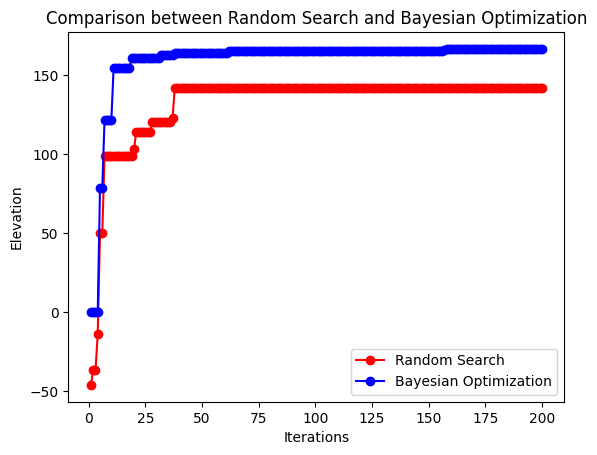

In [47]:
import matplotlib_inline
random_elevation = []
for param in param_list:
    random_elevation.append(request_elevation(param["latitude"],param["longitude"]))

max_cumulative_elevation_per_iteration = np.maximum.accumulate(random_elevation)
y_bo = np.maximum.accumulate(-opt.func_vals).ravel()
# define iteration number
xs = np.arange(1,len(random_elevation) + 1,1)


plt.plot(xs, max_cumulative_elevation_per_iteration, 'o-', color = 'red', label='Random Search')
plt.plot(xs, y_bo, 'o-', color = 'blue', label='Bayesian Optimization')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Elevation')
plt.title('Comparison between Random Search and Bayesian Optimization')
plt.show()

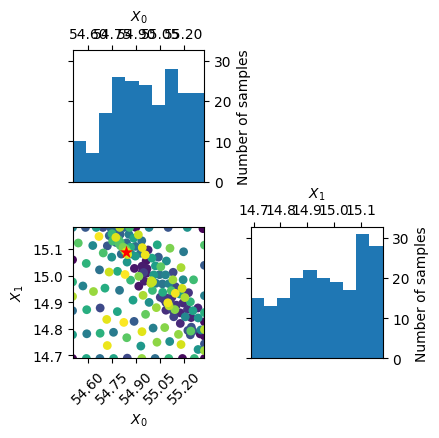

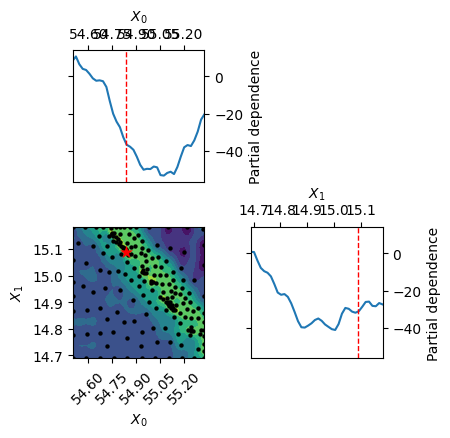

In [101]:
from skopt.plots import plot_objective, plot_evaluations

# 1. Shows where the optimizer spent most of its time
plot_evaluations(opt, bins=10)
plt.show()

# 2. Shows the predicted landscape (the surrogate model)
plot_objective(opt)
plt.show()

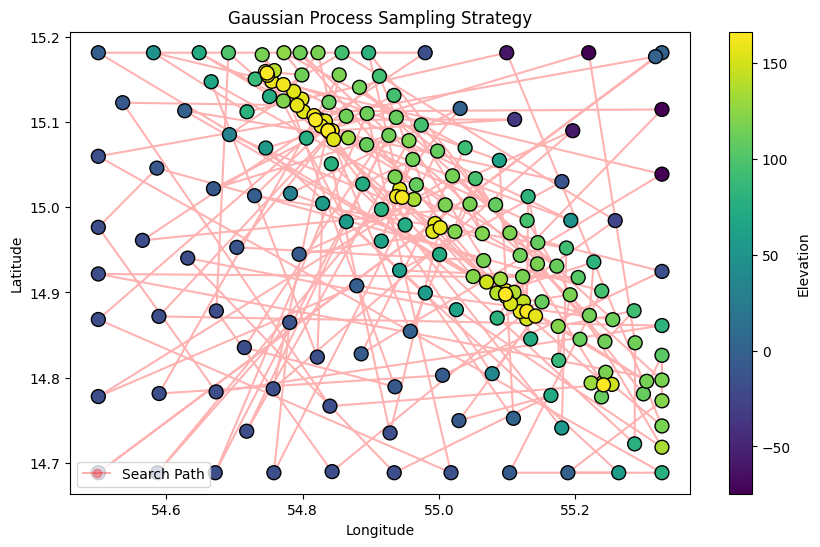

In [102]:
import matplotlib.pyplot as plt

# Extract the points sampled (x) and the results (y)
# opt.x_iters is a list of [lat, alt] pairs
# opt.func_vals is the elevation (negative because of the objective function)
sampled_points = np.array(opt.x_iters)
elevations = -opt.func_vals  # Convert back to positive elevation

plt.figure(figsize=(10, 6))
# Plot the path of the optimizer
plt.plot(sampled_points[:, 0], sampled_points[:, 1], 'ro-', alpha=0.3, label='Search Path')
# Scatter plot colored by elevation to see where the high points are
sc = plt.scatter(sampled_points[:, 0], sampled_points[:, 1], 
                 c=elevations, cmap='viridis', s=100, edgecolors='k', zorder=5)

plt.colorbar(sc, label='Elevation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gaussian Process Sampling Strategy')
plt.legend()
plt.show()

### Surrogate Function

In [103]:
# print(opt.space[0])
# # the line below shows how to encode latitude
# print(opt.space[0][1].transform(['normalize']))
# # the line below shows how to encode the c
# print(opt.space[1][1].transform(['normalize']))
lon_min,lon_max = (14.688672, 15.181072)
lat_min,lat_max = (54.963728, 55.327825)

n_points = 100

lat_range = np.linspace(lat_min, lat_max, n_points)
lon_range = np.linspace(lon_min, lon_max, n_points)



#We start by taking a look a the model subclass of our Bayesian optimization object
print(opt)
#get the last model
model = opt.models[-1]
#To get a plot of the acquisition function we use the model's predict function
#first we define a sensible grid for the first to parameters
#indexing='ij' ensures that x/y axes are not flipped (which is default):
#note that the acqusition function can actually take any value not only integers as it lives in the GP space
#and it is quite fast to evaluate even for many points

# this code will create an array of points to evaluate the function in the normalized space
# the result should be a 6xNpoints array where the first two rows are the n_estimators and max_depth
# the last 4 column are for the categorical variables, to encode 'log2' the first column is set to 1
# the last column will indicate 'gini' as the first option for the criterion
grid = np.array(np.meshgrid(lat_range, lon_range,indexing='ij'))
grid_points = grid.reshape(2, -1).T
grid_norm = np.array([opt.space[i][1].transform(grid_points[:, i]) 
                      for i in range(2)]).T


          fun: -166.3905944824219
            x: [54.83784061252262, 15.089625991033435]
    func_vals: [ 0.000e+00  1.800e+01 ...  1.583e+01 -5.561e+01]
      x_iters: [[np.float64(55.327825), np.float64(15.181072)], [54.5, 14.688672], [55.318382632109476, 15.176465322950158], [54.5, 15.05961337129935], [55.327825, 14.688672], [55.18963558557126, 14.688672], [55.327825, 14.773001145868426], [55.327825, 14.826343412508093], [55.300568138216775, 14.781099505017032], [54.89695266944051, 15.181072], [54.94271460728972, 15.021125922924272], [54.91566259310155, 14.9602161359382], [54.96187603592777, 15.055952014745523], [54.88825076819197, 15.027132486036919], [54.96370001428585, 15.00915400962706], [54.93580999075269, 15.035386868190479], [54.96704246048305, 15.026158398509654], [54.95062529514139, 14.979145066367645], [54.93796311463567, 15.012540304373156], [54.97428800752009, 15.09637909480633], [55.24405035293434, 14.84237432948858], [55.286847121295644, 14.878590588951077], [55.175394

Text(0.5, 1.0, 'Surrogate function std dev')

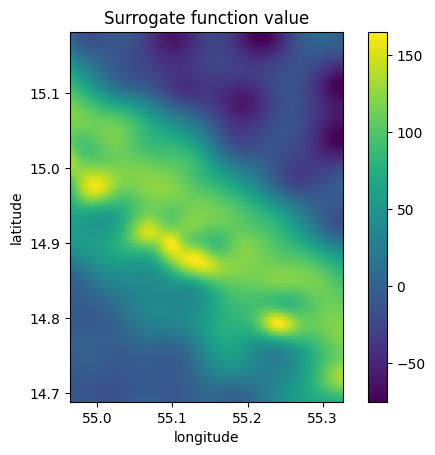

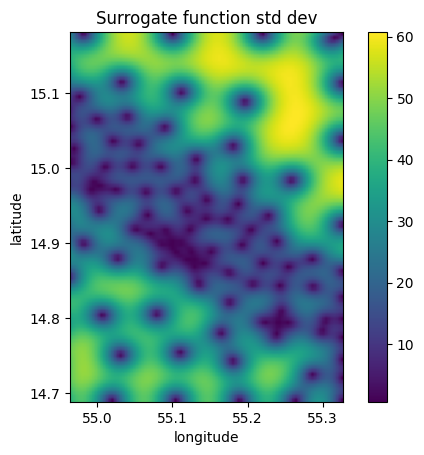

In [104]:
ye, ye_std = model.predict(X=grid_norm, return_std=True)
ye_img = -np.array(ye).reshape(grid[0].shape)
ye_std_img = np.array(ye_std).reshape(grid[0].shape)

plt.figure()
plt.imshow(ye_img.T, origin='lower',extent=[grid[0][0][0],grid[0][-1][0],grid[1][0][0],grid[1][0][-1]])
plt.colorbar()
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.ylim(14.688672, 15.181072)
plt.xlim(54.963728,55.327825)
plt.title('Surrogate function value')

plt.figure()
plt.imshow(ye_std_img.T, origin='lower',extent=[grid[0][0][0],grid[0][-1][0],grid[1][0][0],grid[1][0][-1]])
plt.colorbar()
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title('Surrogate function std dev')

In [105]:
grid_norm.shape

(10000, 2)

Best observed value: -166.3905944824219
grid[0] shape: (100, 100)
grid[1] shape: (100, 100)
grid[0] min/max: 54.9637, 55.3278
grid[1] min/max: 14.6887, 15.1811
Plot extent: [np.float64(14.688672), np.float64(15.181072), np.float64(54.963728), np.float64(55.327825)]


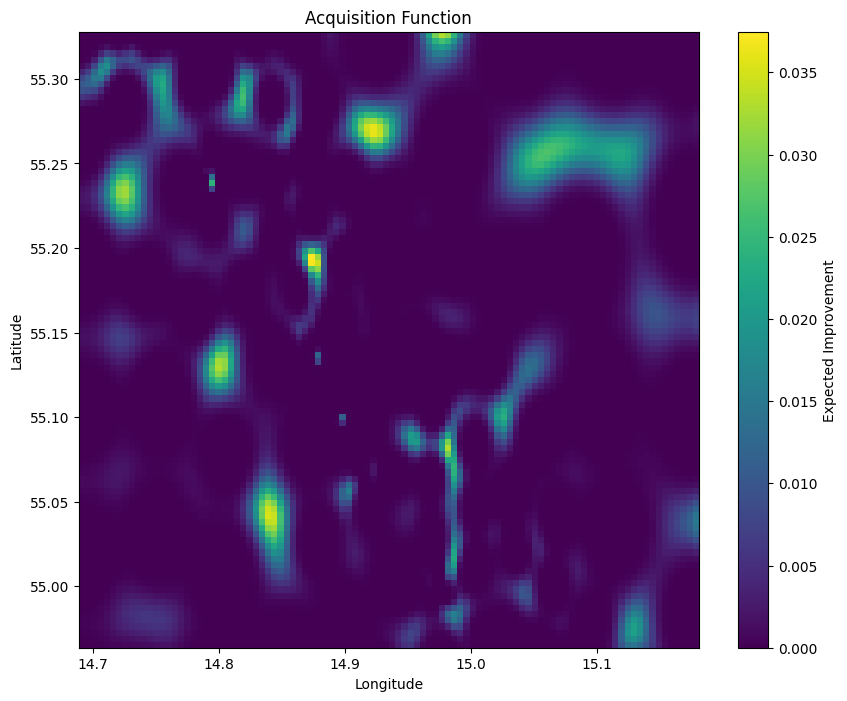

In [106]:
#evaluate the acqusition function using skopt.acquisition.gaussian_ei and plot it
y_opt = np.min(opt.func_vals)
print(f"Best observed value: {y_opt}")  # Should be -166.3905944824219

# Calculate acquisition values
acq_val = skopt.acquisition.gaussian_ei(X=grid_norm, model=model, y_opt=y_opt, xi=0.01)

# Check your grid structure first
print(f"grid[0] shape: {grid[0].shape}")
print(f"grid[1] shape: {grid[1].shape}")
print(f"grid[0] min/max: {grid[0].min():.4f}, {grid[0].max():.4f}")
print(f"grid[1] min/max: {grid[1].min():.4f}, {grid[1].max():.4f}")

# Reshape acquisition values
n_lat = grid[0].shape[0]  # number of latitude points
n_lon = grid[0].shape[1]  # number of longitude points
acq_img = acq_val.reshape(n_lat, n_lon)

# Get the actual extent from your grid
extent = [grid[1].min(), grid[1].max(), grid[0].min(), grid[0].max()]  # [lon_min, lon_max, lat_min, lat_max]
print(f"Plot extent: {extent}")

# Create the plot with a small buffer if needed
if extent[2] == extent[3]:  # if lat_min == lat_max
    # Add a small buffer
    extent[2] -= 0.01
    extent[3] += 0.01

plt.figure(figsize=(10, 8))
im = plt.imshow(acq_img, origin='lower', extent=extent, aspect='auto', cmap='viridis')
plt.colorbar(im, label='Expected Improvement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Acquisition Function')
plt.show()